# Phase 1: Data Preprocessing

In this notebook, I'll be loading my image dataset, applying the necessary transformations, and preparing it for my PyTorch CNN. My goal here is to convert the raw images into normalized tensors so my neural network can process them mathematically.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os

# Let's check if I have a GPU available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I am using device: {device}")

I am using device: cpu


## Defining Transformations

Neural networks expect inputs of a fixed size. I need to resize all my images to 224x224 pixels (which is standard for many CNN architectures), convert them to PyTorch tensors, and normalize the pixel values. This normalization will help my model train faster and stay stable.

In [2]:
# Defining hyper-parameters for my data loading
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Setting up the transformations I want to apply
data_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    # Using standard normalization values for pre-trained PyTorch models
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Loading the Dataset and Splitting

I'm using `datasets.ImageFolder` because it automatically assigns labels based on my folder names (`with_mask` = 0, `without_mask` = 1). After that, I'll split my data into a training set (80%) to teach the model, and a validation set (20%) to test it on images it hasn't seen before.

In [3]:
# Pointing to where I stored my data
data_dir = '../data/'

# Loading the dataset from my folders
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
classes = full_dataset.classes
print(f"Classes I found: {classes}")

# Splitting the dataset (80% train, 20% validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")

# Creating DataLoaders to handle my batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Classes I found: ['with_mask', 'without_mask']
Number of training images: 6042
Number of validation images: 1511


## Visualizing a Batch

It's always a good idea to visualize the data after applying transformations. This way, I can make sure everything loaded correctly before I start building the model. *Note: I have to un-normalize the images here just to display them correctly on screen.*

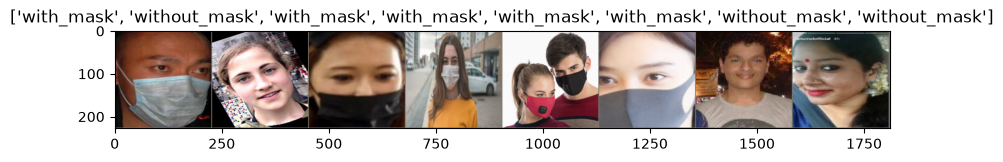

In [4]:
def imshow(inp, title=None):
    """Helper function to show a Tensor as an image."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Un-normalize the image so it looks normal to the human eye
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Grabbing a single batch of my training data
inputs, classes_idx = next(iter(train_loader))

# Making a grid from the batch to display
from torchvision.utils import make_grid
out = make_grid(inputs[:8]) # Just displaying the first 8 images

imshow(out, title=[classes[x] for x in classes_idx[:8]])